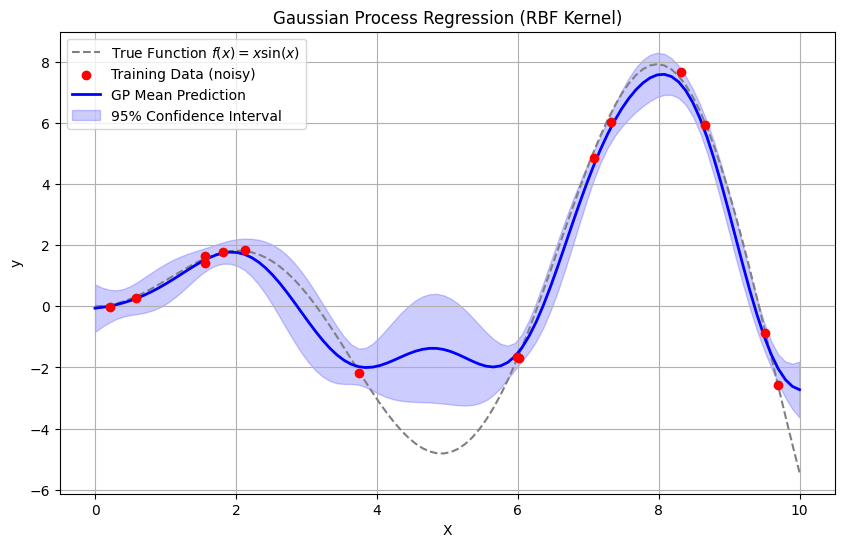

Optimized kernel: RBF(length_scale=0.722)


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

# 1. Generate synthetic data
# True function: y = x * sin(x)
def true_func(x):
    return x * np.sin(x)

# Generate training data (with a bit of noise)
np.random.seed(42)
X_train = np.random.uniform(0, 10, size=(15, 1))
y_train = true_func(X_train).ravel() + np.random.normal(0, 0.1, size=X_train.shape[0])

# Generate test data (fine grid for plotting the prediction curve)
X_test = np.linspace(0, 10, 100).reshape(-1, 1)
y_test_true = true_func(X_test).ravel()

# 2. Define the Kernel and Gaussian Process Regressor
# We add a constant kernel or allow length_scale bounds so it can optimize properly
kernel = RBF(length_scale=1.0, length_scale_bounds=(1e-1, 10.0))

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=0.1,  # Value added to the diagonal of the kernel matrix during fitting (handles noise)
    n_restarts_optimizer=9
)

# 3. Fit to the training data
gp.fit(X_train, y_train)

# 4. Predict on the test data (returning mean and standard deviation)
mean, std = gp.predict(
    X_test,
    return_std=True
)

# 5. Visualize the results
plt.figure(figsize=(10, 6))

# Plot the true function and training points
plt.plot(X_test, y_test_true, label="True Function $f(x) = x \sin(x)$", linestyle="--", color="gray")
plt.scatter(X_train, y_train, color="red", zorder=5, label="Training Data (noisy)")

# Plot the GP mean prediction
plt.plot(X_test, mean, label="GP Mean Prediction", color="blue", lw=2)

# Plot the 95% confidence interval (mean +/- 1.96 * std)
plt.fill_between(
    X_test.ravel(),
    mean - 1.96 * std,
    mean + 1.96 * std,
    alpha=0.2,
    color="blue",
    label="95% Confidence Interval"
)

plt.title("Gaussian Process Regression (RBF Kernel)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend(loc="upper left")
plt.grid(True)
plt.show()

# Print the optimized kernel parameters
print(f"Optimized kernel: {gp.kernel_}")